# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import random 
import numpy as np
from scipy.stats import probplot


# Configure settings to standardize plot appearance
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_17011/3948125710.py:2: DtypeWarning: Columns (11,13,16,17,18,19,20,21,22,24,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/cleaned_2003_present.csv")


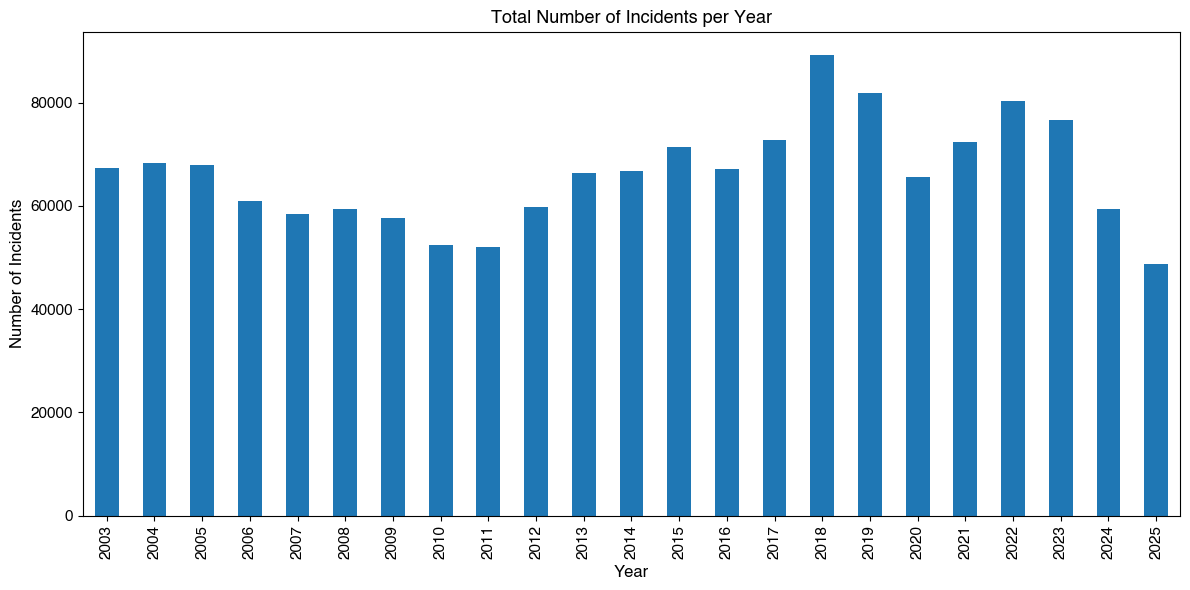

In [30]:
# Upload the data
df = pd.read_csv("data/processed/cleaned_2003_present.csv")
df['Incident Date'] = pd.to_datetime(df['Incident Date'])

# Total number of incidents per year
incidents_per_year = df['Incident Year'].value_counts().sort_index()

# Bar chart showing the incidents by year
incidents_per_year.plot(kind='bar', figsize=(12,6))
plt.ylabel('Number of Incidents')
plt.xlabel('Year')
plt.title('Total Number of Incidents per Year')

plt.tight_layout()
plt.show()

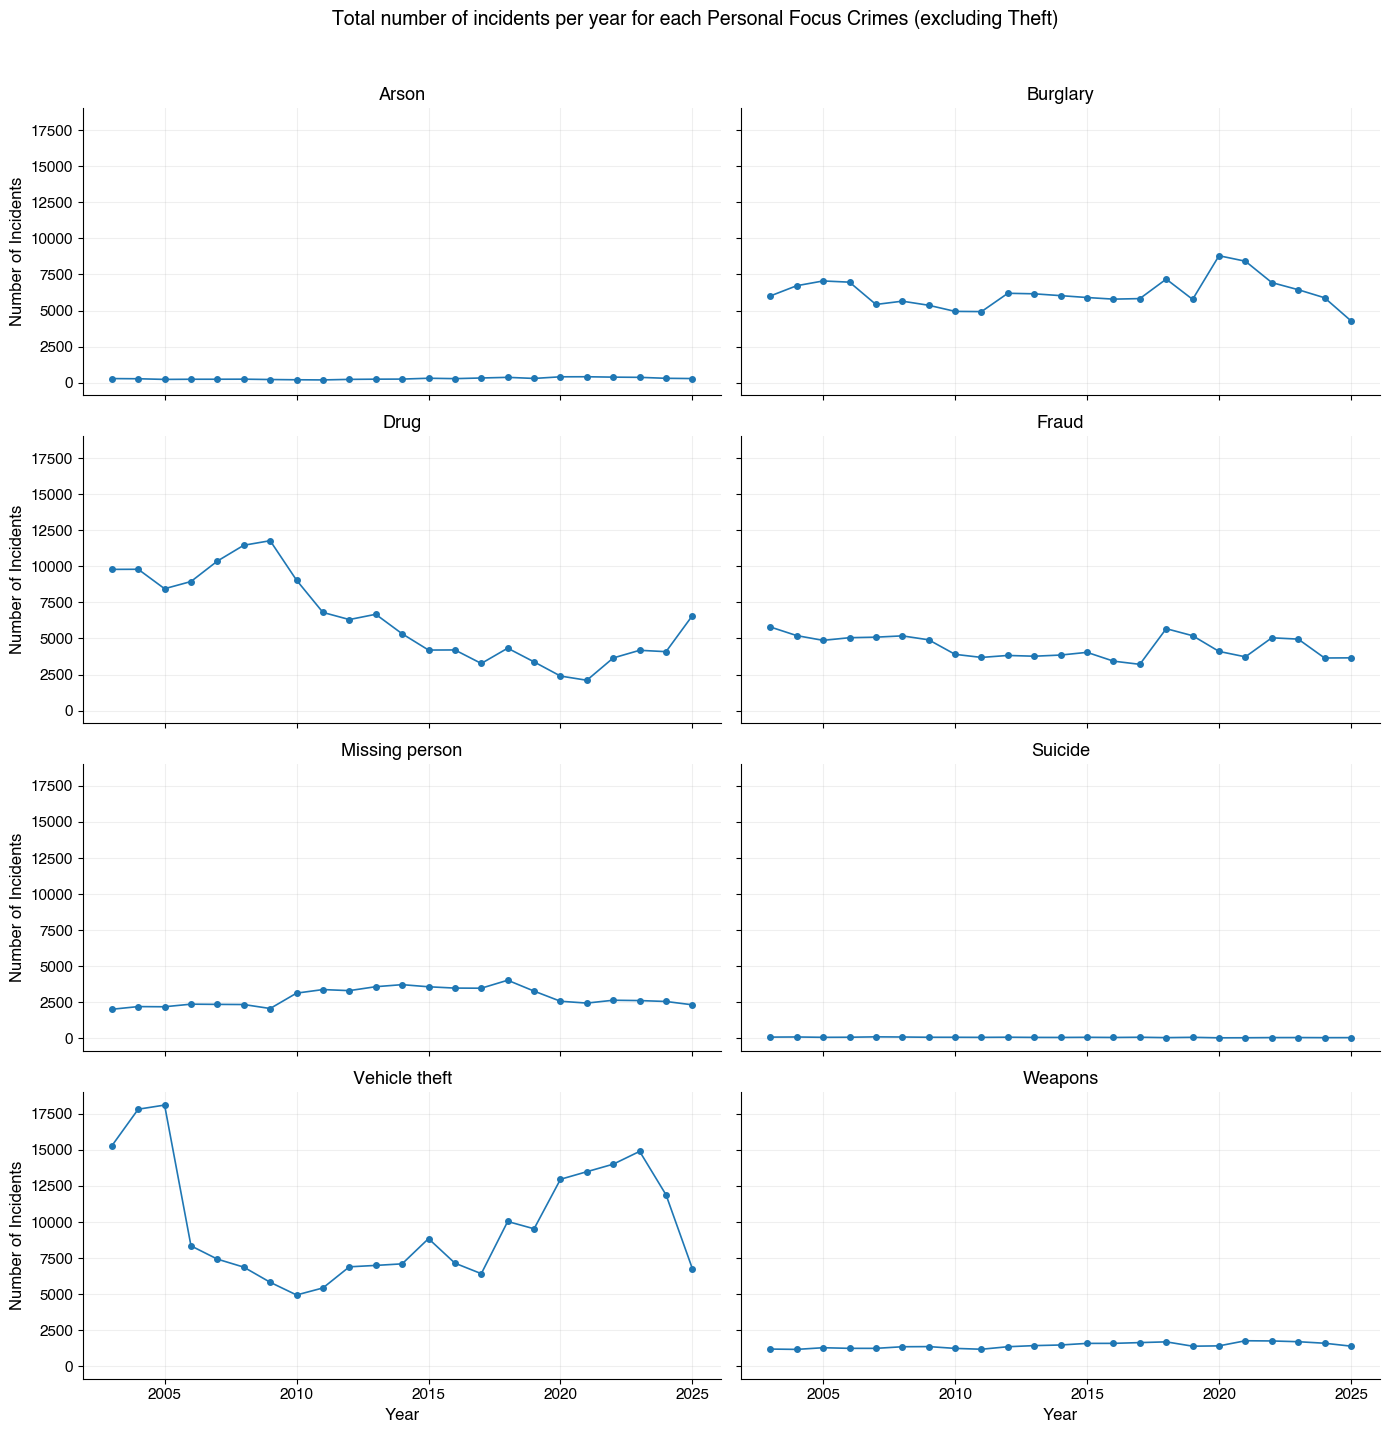

In [31]:
# Create a dataframe that calculates yearly incident counts per category
df_plot = (
    df[['Incident Date', 'Incident Category']]
        .assign(Year=lambda x: x['Incident Date'].dt.year)
        .groupby(['Year', 'Incident Category'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
)

# Remove theft category to plot it separately
df_plot_rest = df_plot.drop(columns=['theft'])

cols = df_plot_rest.columns
years = df_plot_rest.index
labels = [str(c).capitalize() for c in cols]
n = len(labels)
ncols = 2
nrows = math.ceil(n/ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True, sharey=True)
axes = axes.ravel()

# Plot for each type of crime
for ax, col, label in zip(axes, cols, labels):
       ax.plot(years, df_plot_rest[col],marker="o", markersize=4, linewidth=1.2)
       ax.set_title(label)
       ax.grid(True, alpha=0.2)

       ax.spines['top'].set_visible(False)
       ax.spines['right'].set_visible(False)
       
for ax in axes[::ncols]:
       ax.set_ylabel('Number of Incidents')
       
for ax in axes[-ncols:]:
       ax.set_xlabel('Year')

fig.suptitle('Total number of incidents per year for each Personal Focus Crimes (excluding Theft)', fontsize=14, y=1.02)   
fig.tight_layout()    
plt.show()

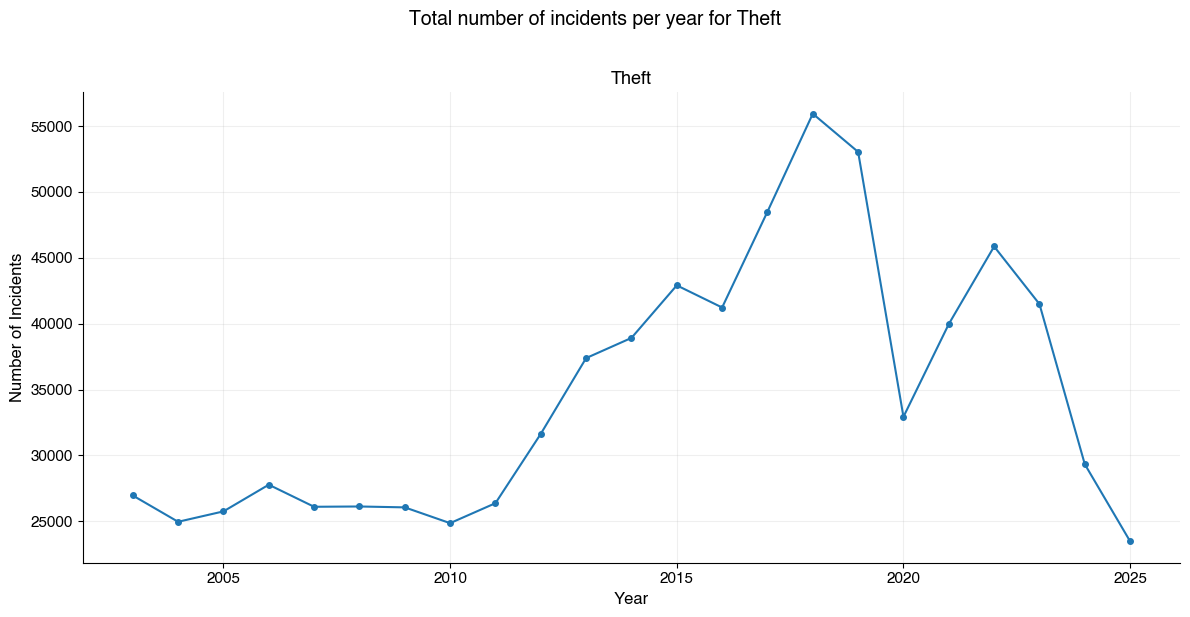

In [32]:
# Plot theft on its own
df_plot_theft = df_plot['theft']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(years, df_plot_theft, marker="o", markersize=4, linewidth=1.5)

ax.set_title('Theft')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')

ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Total number of incidents per year for Theft', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


The plots reveal several notable patterns across crime categories. Theft clearly stands out with substantially higher incident counts than all other categories, which is why it was displayed separately. If it would be plotted on the same scale as the others, variation in the smaller categories would be almost invisible. However, even after separating theft, differences in magnitude remain among the other categories, with arson, suicide and weapons still a bit flat. 

Theft shows a steady increase from around 2011 to a peak around 2018–2019, followed by a sharp decline in 2020. A possible explanation for this drop is the impact of COVID-19 restrictions, which reduced mobility, tourism, and overall social activity, thereby limiting opportunities for theft. Although the 2018 peak could potentially reflect reporting inconsistencies or data recounts, the upward trend had been present since 2011, suggesting that the increase was likely part of a broader pattern.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [33]:
# Count relative frequencies of each category
P_crime = df['Incident Category'].value_counts(normalize=True)

P_crime_given_district = (
    df
    .groupby('Police District')['Incident Category']
    .value_counts(normalize=True) #normalize deilir sjálfkrafa með heildarfjölda
    .unstack(fill_value=0)
)

ratio = P_crime_given_district.div(P_crime, axis=1)


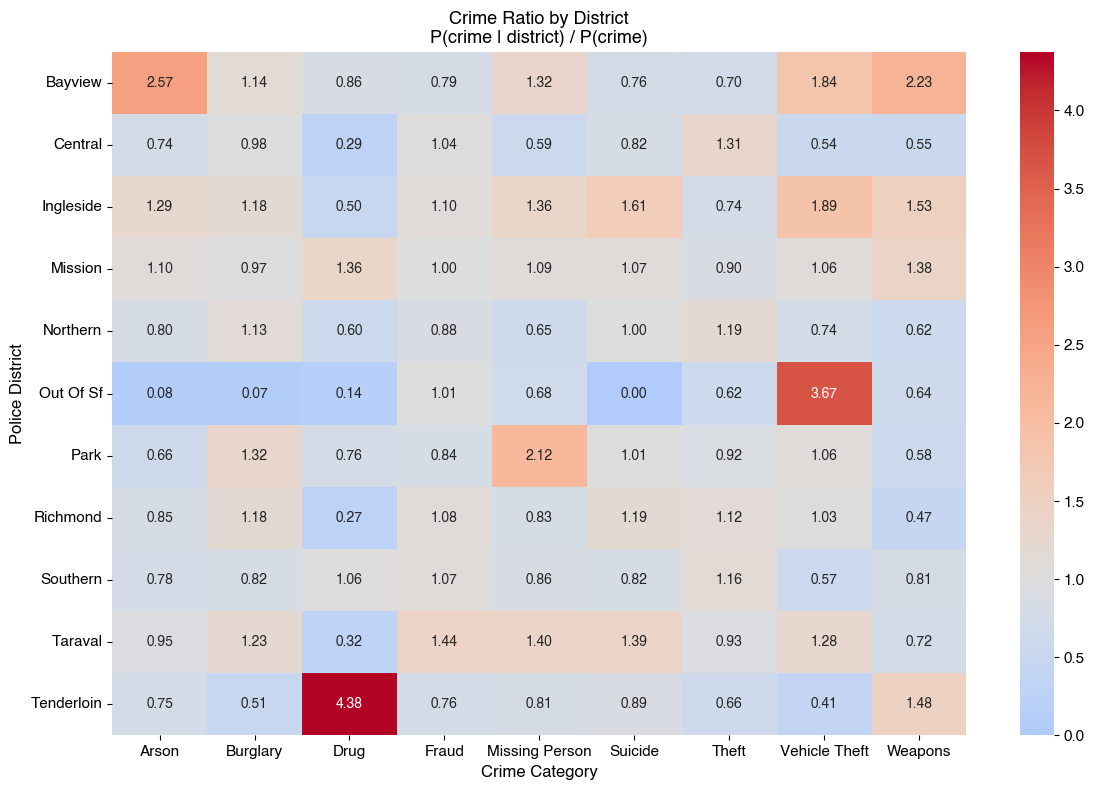

In [34]:

plt.figure(figsize=(12,8))

# Convert labels into Title case
ratio.index = ratio.index.str.title()
ratio.columns = ratio.columns.str.title()

# Generate heatmap
sns.heatmap(
    ratio,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=1
)

plt.title("Crime Ratio by District\nP(crime | district) / P(crime)")
plt.ylabel("Police District")
plt.xlabel("Crime Category")
plt.tight_layout()
plt.show()

### 

Tenderloin clearly stands out, it has the highest ratio for drug offenses. The ratio of 4.38 indicates that drug crimes occur in this district at more than four times the citywide average. When looking into it we found that the area has a reputation for high levels of homelessness and open-air drug markets, and it has been widely described as the center of the fentanyl crisis in San Francisco.

Despite the extremely high ratio for drug offenses, other crime categories in Tenderloin do not deviate as strongly from the city average. Most of its other crime ratios are close to or even below 1. 

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

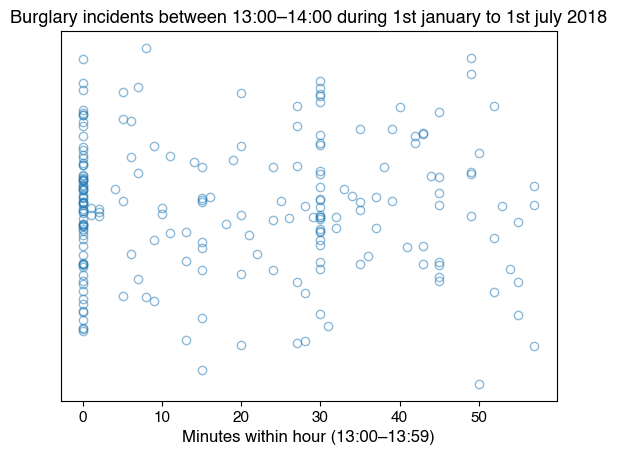

In [35]:
# ------ Jitter Plot ------

# Selected crime and time interval
crime = 'vehicle theft'
start_date = '2018-01-01'
end_date = '2018-07-01'
hour = '13'

# Create a mask to filter based on the above
mask = (
    (df['Incident Category'] == crime)
    & (df['Incident Date'] >= start_date)
    & (df['Incident Date'] < end_date)
    & (df['Incident Time'].fillna('').str[:2] == hour)
)

df_filtered = df.loc[mask]

x = df_filtered['Incident Time'].str[3:].astype('int')
y = np.random.normal(loc=0, scale=0.05, size=len(x))

    
# Count no of instances
fig, ax = plt.subplots()
ax.plot(x, y, marker ='o', linestyle='none',  markerfacecolor='none', alpha=0.5)
ax.yaxis.set_visible(False)
ax.set_xlabel('Minutes within hour (13:00–13:59)')
ax.set_title('Burglary incidents between 13:00–14:00 during 1st january to 1st july 2018')

plt.show()

##
For this analysis, we created a jitter plot of incident times within a single hour for one selected crime category. The plot reveals a clear clustering of incidents at specific minutes, particularly exactly on the hour (13:00) and on the half hour (13:30). There are also noticeable, though smaller, clusters at 15 and 45 minutes past the hour.

This pattern suggests that incident times are often recorded in rounded intervals rather than at the exact minute the event occurred. Instead of reflecting precise timestamps, the data appears to contain a degree of reporting approximation. This likely indicates that officers sometimes estimate or round the time of occurrence. As a result, the dataset may not represent true minute-level precision.

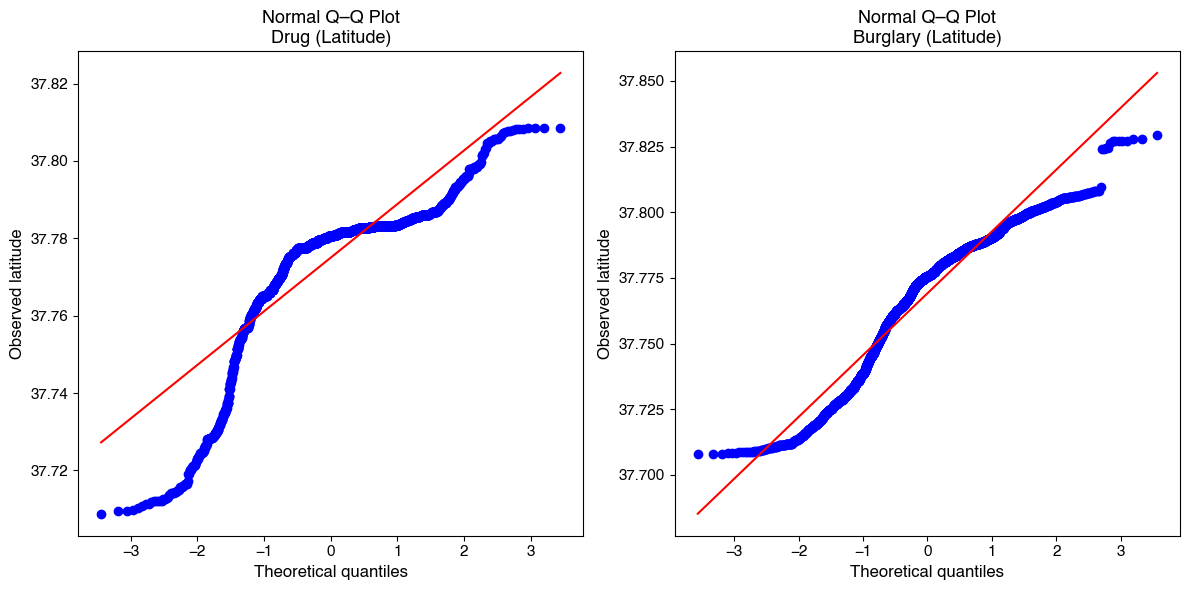

In [36]:
# ------ Probability Plot ------

# Selected crimes and time interval
crimes = ['drug', 'burglary']
start_date = '2018-01-01'
end_date = '2018-07-01'

# Create a mask to filter the dataframe
mask = (
    (df['Incident Category'].isin(crimes))
    & (df['Incident Date'] >= start_date)
    & (df['Incident Date'] < end_date)
)

df_filtered = df.loc[mask].copy()

# Ensure that latitude and longitudes are numeric
df_filtered['Latitude'] = pd.to_numeric(df_filtered['Latitude'], errors='coerce')
df_filtered['Longitude'] = pd.to_numeric(df_filtered['Longitude'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, crime_i in zip(axes, crimes):
    X = df_filtered.loc[
        df_filtered['Incident Category'] == crime_i,
        'Latitude'
    ]
    X = pd.to_numeric(X, errors='coerce').dropna()

    probplot(X, dist="norm", plot=ax)
    ax.set_title(f"Normal Q–Q Plot\n{crime_i.title()} (Latitude)")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Observed latitude")

plt.tight_layout()
plt.show()

The QQ plots compare the latitude distribution of two crime types; drugs and burglary, to a normal distribution. In this context, the reference distribution is the normal (Gaussian) distribution. If the points were to fall exactly on the straight line, it would indicate that crime incidents are geographically distributed in a symmetric, bell-shaped pattern across latitudes in San Francisco. This would mean that most incidents cluster around a central north–south corridor, with progressively fewer cases occurring toward the city’s northern and southern edges.

For drug offenses, the points deviate substantially from the line at the lower end of the distribution but align a bit more closely in the middle. This suggests that drug-related crimes are not evenly spread across the city’s latitude range. The deviation in the lower tail indicates fewer incidents in the extreme southern parts of the city than a normal distribution would predict.

Burglary aligns more closely with the reference line overall, although it starts slightly above the line and ends slightly below it. This pattern suggests mild skewness but a distribution that is closer to normal compared to drug crimes. In other words, burglary appears to be more geographically dispersed across the city, while drug crimes are more spatially concentrated.

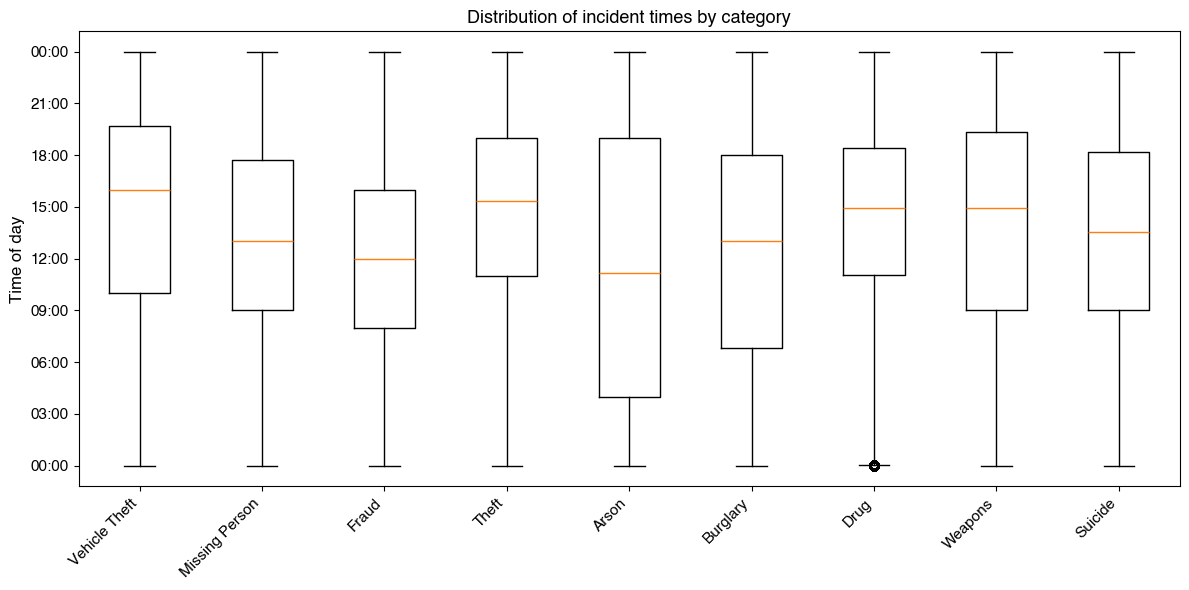

In [37]:
# ------ Box Plot ------

# Convert incident time to datetime
dt = pd.to_datetime(df['Incident Time'],format="%H:%M",errors="coerce")

focus_crimes = df['Incident Category'].unique()

# Dataframe to calculate time of the day as fractional hours of the day
df_time_of_day = pd.DataFrame({
    'time_of_day': dt.dt.hour + (dt.dt.minute * 60 + dt.dt.second)/ 3600.0,
    'datetime': dt,
    'Incident Category': df['Incident Category']
})

# Collect time-of-day values for each crime category
data = [
    df_time_of_day.loc[df_time_of_day['Incident Category'] == crime, 'time_of_day']
                  .dropna()
                  .to_numpy()
    for crime in focus_crimes
]

# Convert labels to title case
focus_crimes = [crime.title() for crime in focus_crimes]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, labels=focus_crimes)

# Format y-axis as 3-hour intervals
yticks = np.arange(0, 25, 3)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int((y) % 24):02d}:00" for y in yticks])

ax.set_ylabel("Time of day")
ax.set_title("Distribution of incident times by category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


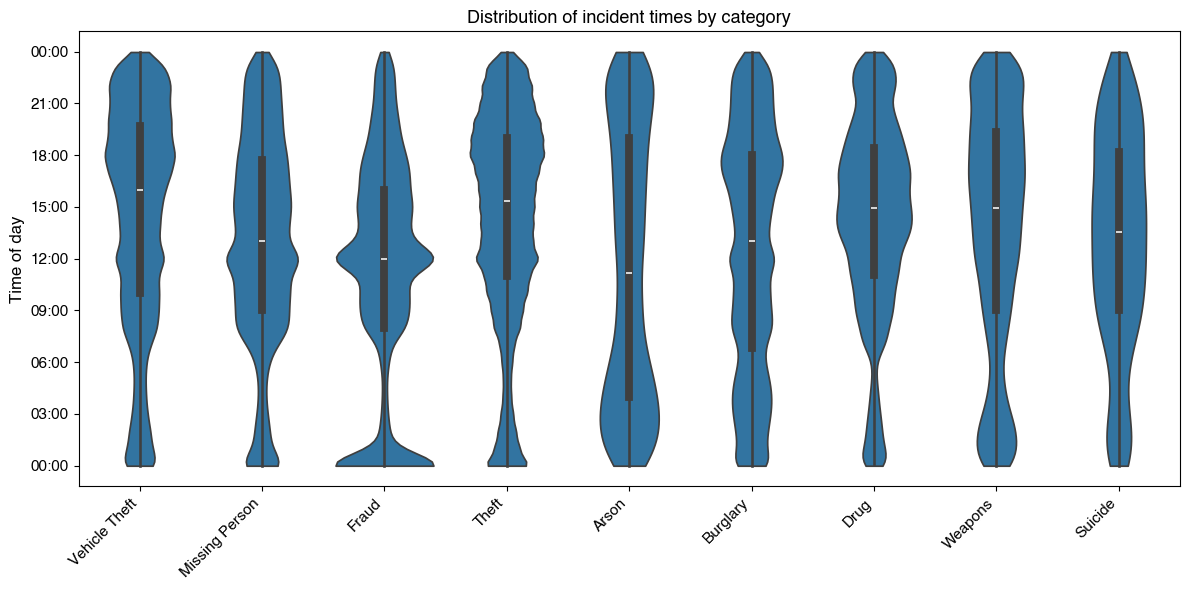

In [38]:
# ------ Violin Plot ------
# Capitalize crime category labels
df_time_of_day['Incident Category'] = df_time_of_day['Incident Category'].str.title()

plt.figure(figsize=(12, 6))

sns.violinplot(data=df_time_of_day, x='Incident Category', y='time_of_day', cut=0)

# Formaty-axis as 3-hour intervals
yticks = np.arange(0, 25, 3)
plt.yticks(yticks, [f"{int(y % 24):02d}:00" for y in yticks])

plt.xlabel("")
plt.ylabel("Time of day")
plt.title("Distribution of incident times by category")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The box plots show that the average time-of-day for all crime categories falls roughly between noon and 15:00. However, this similarity is somewhat misleading. Time-of-day is a circular variable, where 23:59 and 00:01 are only minutes apart, yet numerically they appear far from each other. Because a standard box plot treats time as a linear variable from 0 to 24, it does not handle the wrap-around at midnight well.

As a result, crimes that primarily occur late at night (for example around 23:00–02:00) may appear artificially spread out, and their median may fall closer to midday than expected. This makes the mean and median less informative for interpreting daily crime patterns.

Although the box plots highlight differences in variability across crime types, for example arson appears more evenly distributed throughout the day, while drug offenses are concentrated within a narrower time range, they do not clearly indicate when crime levels are highest. As a result, the visualization is limited in its ability to identify whether incidents tend to peak during nighttime, business hours, or early morning periods.

Therefore, we also created a violin plot to better examine the full distribution of incident times. Unlike box plots, violin plots display the density of observations at each time of day, making peak hours more visible. For example, vehicle theft and theft show stronger concentration in the late afternoon and evening while some categories display multiple peaks throughout the day.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

In [39]:
# Filter thefts only
theft_df = df[df['Incident Category'] == 'theft']

# Remove extreme outliers (rough SF peninsula bounding box)
theft_df = theft_df[
    (theft_df['Latitude'] > 37.6) &
    (theft_df['Latitude'] < 37.84) &
    (theft_df['Longitude'] > -122.55) &
    (theft_df['Longitude'] < -122.35)
]

# Create bins with 100m resolution
lat_bins = np.linspace(theft_df['Latitude'].min(),
                       theft_df['Latitude'].max(),
                       100)

lon_bins = np.linspace(theft_df['Longitude'].min(),
                       theft_df['Longitude'].max(),
                       100)

# Create a 2D histogram
H, xedges, yedges = np.histogram2d(
    theft_df['Latitude'],
    theft_df['Longitude'],
    bins=[lat_bins, lon_bins]
)

# Flatten grid counts
crime_counts = H.flatten()

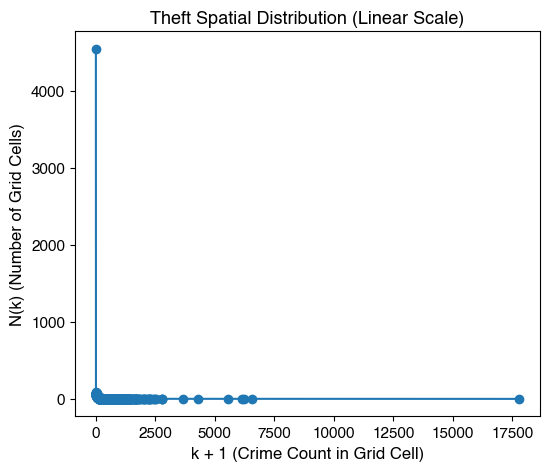

In [40]:
# Keep zeros instead of filtering them out
unique, counts = np.unique(crime_counts, return_counts=True)

k_values = unique
N_k = counts

plt.figure(figsize=(6,5))
plt.plot(k_values + 1, N_k, marker='o')
plt.xlabel("k + 1 (Crime Count in Grid Cell)")
plt.ylabel("N(k) (Number of Grid Cells)")
plt.title("Theft Spatial Distribution (Linear Scale)")
plt.show()

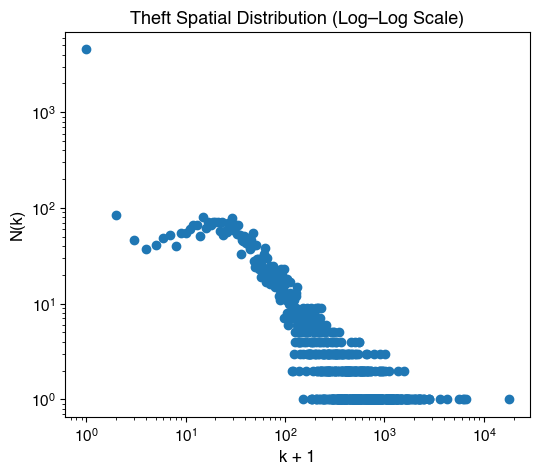

In [41]:
# Generate a plot for the spatial distribution on a log-log scale
plt.figure(figsize=(6,5))
plt.loglog(k_values + 1, N_k, marker='o', linestyle='')
plt.xlabel("k + 1")
plt.ylabel("N(k)")
plt.title("Theft Spatial Distribution (Log–Log Scale)")
plt.show()

The linear plot shows a very large spike at k=0, meaning that most grid cells contain no theft incidents at all. This is partly because San Francisco is not rectangular, and many of the grid cells fall over the ocean. However, when focusing only on the peninsula, the majority of cells still contain very few or zero incidents, indicating that theft is not evenly distributed across space.

The log–log plot provides further insight into the spatial distribution. If theft followed a perfect power-law distribution, the points would align approximately along a straight line in the log–log plot. Instead, the distribution curves downward rather than forming a straight line, especially for large values of k. This indicates that the spatial distribution does not perfectly follow a power law.

A small number of grid cells account for a disproportionate share of theft incidents, while the vast majority of cells experience little to no crime. This implies that crime is clustered in hotspots rather than spread evenly across the city. As a result, the overall crime pattern is dominated by a few high-incident locations, while most areas remain relatively unaffected.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

In [42]:
# Function to fit a regression line 
def compute_linear_fit(x,y):
    N = len(x)
    x_mean = x.mean()
    y_mean = y.mean()
    
    den = np.sum(x * y) - N *x_mean*y_mean
    nom = np.sum(x*x) - N * x_mean**2
    
    a = den/nom
    
    b = y_mean - a * x_mean
    
    return a, b

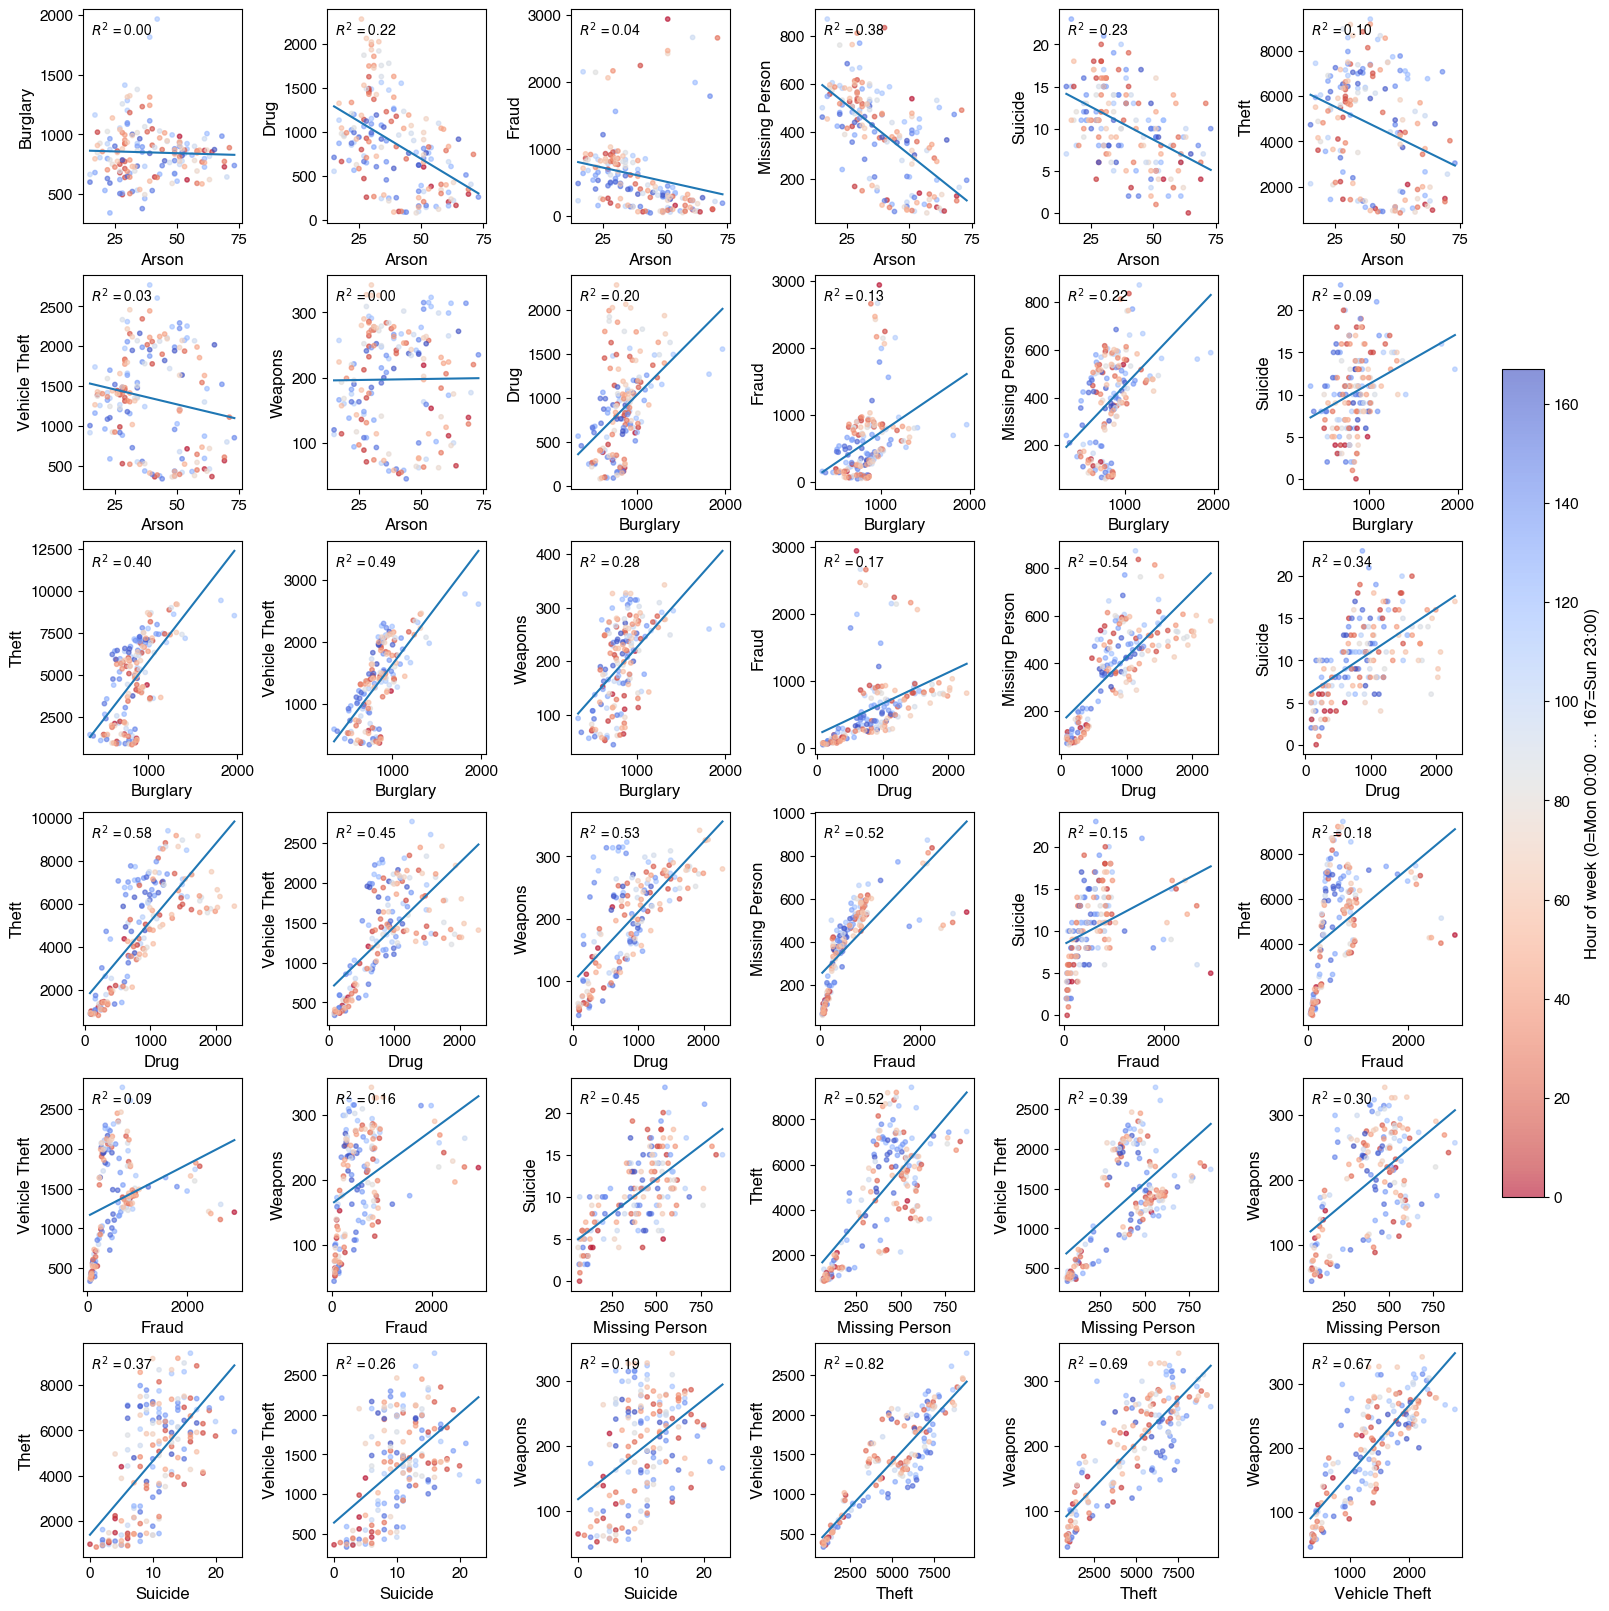

In [43]:
import itertools
from sklearn.metrics import r2_score
from matplotlib.colors import Normalize

# Extract hours from incident time
dt = pd.to_datetime(df['Incident Time'],format="%H:%M",errors="coerce")
df["Incident Hour"] = dt.dt.hour

# Count incidents by day, hour and category
df_hours = (
    df.groupby(["Incident Day of Week", "Incident Hour", "Incident Category"])
      .size()
      .unstack(fill_value=0)
)

# 9 categories selected to compare pairwise
cols9 = df_hours.columns[:9]
X = df_hours[cols9]
pairs = list(itertools.combinations(cols9, 2))

# Build hour of week index for coloring
day_vals = df_hours.index.get_level_values(0)
hour_vals = df_hours.index.get_level_values(1)

day_map = {
    "Monday": 0, 
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3, 
    "Friday": 4, 
    "Saturday": 5,
    "Sunday": 6
}
day_num = day_vals.map(day_map)

hour_of_week = day_num.to_numpy() * 24 + pd.Series(hour_vals, index=df_hours.index).to_numpy()
norm = Normalize(vmin=0, vmax=167)

# Plot the pairwise graphs
fig, axes = plt.subplots(6, 6, figsize=(16, 16), constrained_layout=True)
axes = axes.ravel()

sc = None
for ax, (x_col, y_col) in zip(axes, pairs):
    x = X[x_col]
    y = X[y_col]

    # Drop missing values
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    c = hour_of_week[mask.to_numpy()]

    # Fit a simple linear model and compute R^2
    a, b = compute_linear_fit(x, y)
    y_pred = a * x + b
    r2 = r2_score(y, y_pred)

    sc = ax.scatter(
        x, y,
        c=c,
        cmap="coolwarm_r",
        norm=norm,
        alpha=0.6,
        s=10
    )

    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b)

    ax.set_xlabel(x_col.title())
    ax.set_ylabel(y_col.title())
    ax.tick_params(labelbottom=True)

    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        va="top"
    )
    
# Hide any unused axes
for ax in axes[len(pairs):]:
    ax.set_visible(False)

# Add a shared colorbar
used_axes = axes[:len(pairs)] 
cbar = fig.colorbar(sc, ax=used_axes, fraction=0.03, pad=0.02, shrink=0.85)
cbar.set_label("Hour of week (0=Mon 00:00 … 167=Sun 23:00)")

plt.show()

The pair of crimes with the strongest weekly correlation is theft and vehicle theft, with an $R^2$ value of 0.82. This indicates a very similar weekly rhythm, meaning that these crimes tend to rise and fall together across the 168 hours of the week. This makes a lot of sense as both crimes are likely influenced by similar factors. Their peaks likely occur during busy hours or weekends when opportunities increase.

There is also a relatively strong correlation between theft and weapons offenses ($R^2$=0.69) and between vehicle theft and weapons offenses ($R^2$=0.67). This suggests that weapons offenses tend to follow a similar weekly rhythm as theft and vehicle, likely influenced by similar opportunity-driven factors, such as increased social activity, nightlife, or higher public presence during certain hours of the week.

In contrast, most crime types show very low $R^2$ values when compared with suicide, indicating almost no shared weekly rhythm. This also makes intuitive sense, as suicide is generally driven by fundamentally different underlying factors than other crime categories.